# Projet ETL + ML (A à Z)
Notebook reconstruit pour chargement volume + entraînement + visualisations.

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv(override=True)

import pandas as pd
from IPython.display import display
from sqlalchemy import create_engine, text

In [2]:
# 1) Extract + nettoyage
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin1', low_memory=False)
df_clean = df.copy()
df_clean.columns = [c.strip() for c in df_clean.columns]
text_cols = df_clean.select_dtypes(include=['object', 'string']).columns
for c in text_cols:
    df_clean[c] = df_clean[c].astype('string').str.strip()
df_clean = df_clean.replace({'': pd.NA, 'None': pd.NA, 'nan': pd.NA})
for c in ['order date (DateOrders)', 'shipping date (DateOrders)']:
    if c in df_clean.columns:
        df_clean[c] = pd.to_datetime(df_clean[c], errors='coerce')
all_empty_cols = df_clean.columns[df_clean.isna().all()].tolist()
if all_empty_cols:
    df_clean = df_clean.drop(columns=all_empty_cols)
print('df_clean shape:', df_clean.shape)
display(df_clean.head(5))

df_clean shape: (180519, 52)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,COMPLETE,NaN,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,PENDING,NaN,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,CLOSED,NaN,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,COMPLETE,NaN,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,PENDING_PAYMENT,NaN,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-15 11:24:00,Standard Class


In [3]:
# 2) Connexion Neon

DATABASE_URL = os.getenv('NEON_DATABASE_URL')
if not DATABASE_URL:
    raise ValueError('Définis NEON_DATABASE_URL avant de continuer.')
engine = create_engine(DATABASE_URL, pool_pre_ping=True, future=True)
with engine.connect() as conn:
    conn.execute(text('SELECT 1'))
print('Connexion Neon OK ✅')

Connexion Neon OK ✅


In [4]:
# 3) Préparer dimensions
dates_order = df_clean['order date (DateOrders)'].dt.normalize()
dates_ship = df_clean['shipping date (DateOrders)'].dt.normalize()
all_dates = pd.concat([dates_order, dates_ship], ignore_index=True).dropna().drop_duplicates()
dim_date = pd.DataFrame({'full_date': pd.to_datetime(all_dates).sort_values()})
dim_date['date_key'] = dim_date['full_date'].dt.strftime('%Y%m%d').astype(int)
dim_date['day_of_month'] = dim_date['full_date'].dt.day
dim_date['month_num'] = dim_date['full_date'].dt.month
dim_date['month_name'] = dim_date['full_date'].dt.month_name()
dim_date['quarter_num'] = dim_date['full_date'].dt.quarter
dim_date['year_num'] = dim_date['full_date'].dt.year
dim_date['week_of_year'] = dim_date['full_date'].dt.isocalendar().week.astype(int)
dim_date['day_of_week_num'] = dim_date['full_date'].dt.dayofweek + 1
dim_date['day_of_week_name'] = dim_date['full_date'].dt.day_name()
dim_date = dim_date[['date_key','full_date','day_of_month','month_num','month_name','quarter_num','year_num','week_of_year','day_of_week_num','day_of_week_name']].drop_duplicates()

dim_customer = df_clean[['Customer Id','Customer Fname','Customer Lname','Customer Email','Customer Segment','Customer City','Customer State','Customer Country','Customer Street','Customer Zipcode']].copy()
dim_customer.columns = ['customer_id_nk','customer_fname','customer_lname','customer_email','customer_segment','customer_city','customer_state','customer_country','customer_street','customer_zipcode']
dim_customer['customer_zipcode'] = dim_customer['customer_zipcode'].astype('string')
dim_customer = dim_customer.drop_duplicates(subset=['customer_id_nk'])

dim_product = df_clean[['Product Card Id','Product Name','Product Price','Product Status','Product Image','Product Category Id','Category Id','Category Name','Department Id','Department Name']].copy()
dim_product.columns = ['product_card_id_nk','product_name','product_price','product_status','product_image','product_category_id_nk','category_id_nk','category_name','department_id_nk','department_name']
dim_product = dim_product.drop_duplicates(subset=['product_card_id_nk'])

dim_order_status = df_clean[['Order Status','Delivery Status','Type']].copy()
dim_order_status.columns = ['order_status','delivery_status','payment_type']
dim_order_status = dim_order_status.drop_duplicates()

dim_shipping_mode = df_clean[['Shipping Mode']].copy()
dim_shipping_mode.columns = ['shipping_mode']
dim_shipping_mode = dim_shipping_mode.drop_duplicates()

dim_market_location = df_clean[['Market','Order Region','Order Country','Order State','Order City','Order Zipcode','Latitude','Longitude']].copy()
dim_market_location.columns = ['market','order_region','order_country','order_state','order_city','order_zipcode','latitude','longitude']
dim_market_location['order_zipcode'] = dim_market_location['order_zipcode'].astype('string')
dim_market_location = dim_market_location.drop_duplicates()

print('Dimensions prêtes ✅')
print(dim_date.shape, dim_customer.shape, dim_product.shape, dim_order_status.shape, dim_shipping_mode.shape, dim_market_location.shape)

Dimensions prêtes ✅
(1133, 10) (20652, 10) (118, 10) (23, 3) (4, 1) (64990, 8)


In [5]:
# 4) Load DWH (dimensions puis fact)
if 'engine' not in globals() or engine is None:
    raise ValueError("Connexion Neon non initialisée. Exécute d'abord la cellule 2.")

with engine.begin() as conn:
    for tbl in ['fact_order_item','dim_market_location','dim_shipping_mode','dim_order_status','dim_product','dim_customer','dim_date']:
        conn.execute(text(f'DELETE FROM dwh.{tbl};'))

dim_date.to_sql('dim_date', engine, schema='dwh', if_exists='append', index=False, method='multi', chunksize=5000)
dim_customer.to_sql('dim_customer', engine, schema='dwh', if_exists='append', index=False, method='multi', chunksize=5000)
dim_product.to_sql('dim_product', engine, schema='dwh', if_exists='append', index=False, method='multi', chunksize=5000)
dim_order_status.to_sql('dim_order_status', engine, schema='dwh', if_exists='append', index=False, method='multi', chunksize=5000)
dim_shipping_mode.to_sql('dim_shipping_mode', engine, schema='dwh', if_exists='append', index=False, method='multi', chunksize=5000)
dim_market_location.to_sql('dim_market_location', engine, schema='dwh', if_exists='append', index=False, method='multi', chunksize=5000)
print('Dimensions insérées ✅')

# Lookups (dédupliqués pour éviter les jointures many-to-many)
dim_date_db = pd.read_sql('SELECT date_key, full_date FROM dwh.dim_date', engine)
dim_date_db['full_date'] = pd.to_datetime(dim_date_db['full_date']).dt.normalize()
dim_date_db = dim_date_db.drop_duplicates('full_date')

dim_customer_db = pd.read_sql('SELECT customer_key, customer_id_nk FROM dwh.dim_customer', engine).drop_duplicates('customer_id_nk')
dim_product_db = pd.read_sql('SELECT product_key, product_card_id_nk FROM dwh.dim_product', engine).drop_duplicates('product_card_id_nk')
dim_order_status_db = pd.read_sql('SELECT order_status_key, order_status, delivery_status, payment_type FROM dwh.dim_order_status', engine).drop_duplicates(['order_status','delivery_status','payment_type'])
dim_shipping_mode_db = pd.read_sql('SELECT shipping_mode_key, shipping_mode FROM dwh.dim_shipping_mode', engine).drop_duplicates('shipping_mode')
dim_market_location_db = pd.read_sql(
    'SELECT market_location_key, market, order_region, order_country, order_state, order_city FROM dwh.dim_market_location',
    engine
).sort_values('market_location_key').drop_duplicates(
    subset=['market','order_region','order_country','order_state','order_city'],
    keep='first'
)

# fallback unknown market_location
unknown_key = pd.read_sql(
    "SELECT market_location_key FROM dwh.dim_market_location WHERE market='UNKNOWN' AND order_region='UNKNOWN' AND order_country='UNKNOWN' AND order_state='UNKNOWN' AND order_city='UNKNOWN' LIMIT 1",
    engine
)
if unknown_key.empty:
    pd.DataFrame([{'market':'UNKNOWN','order_region':'UNKNOWN','order_country':'UNKNOWN','order_state':'UNKNOWN','order_city':'UNKNOWN','order_zipcode':None,'latitude':None,'longitude':None}]).to_sql(
        'dim_market_location', engine, schema='dwh', if_exists='append', index=False
    )
    unknown_key = pd.read_sql(
        "SELECT market_location_key FROM dwh.dim_market_location WHERE market='UNKNOWN' AND order_region='UNKNOWN' AND order_country='UNKNOWN' AND order_state='UNKNOWN' AND order_city='UNKNOWN' ORDER BY market_location_key DESC LIMIT 1",
        engine
    )
unk = int(unknown_key.iloc[0, 0])

# Fact slim (réduction RAM)
fact_cols = [
    'order date (DateOrders)','shipping date (DateOrders)',
    'Customer Id','Product Card Id','Order Status','Delivery Status','Type','Shipping Mode',
    'Market','Order Region','Order Country','Order State','Order City',
    'Order Id','Order Item Id','Order Customer Id','Order Item Cardprod Id',
    'Days for shipping (real)','Days for shipment (scheduled)','Late_delivery_risk',
    'Order Item Quantity','Order Item Product Price','Order Item Discount','Order Item Discount Rate',
    'Order Item Total','Sales','Sales per customer','Benefit per order','Order Profit Per Order','Order Item Profit Ratio'
 ]
fact = df_clean[fact_cols].copy()
fact['order_date_norm'] = pd.to_datetime(fact['order date (DateOrders)'], errors='coerce').dt.normalize()
fact['shipping_date_norm'] = pd.to_datetime(fact['shipping date (DateOrders)'], errors='coerce').dt.normalize()

for c in ['Market','Order Region','Order Country','Order State','Order City','Order Status','Delivery Status','Type','Shipping Mode']:
    fact[c] = fact[c].astype('string').str.strip()

# Merges validés many_to_one (anti-explosion de lignes)
fact = fact.merge(
    dim_date_db.rename(columns={'date_key':'order_date_key','full_date':'order_date_norm'}),
    on='order_date_norm', how='left', validate='many_to_one'
 )
fact = fact.merge(
    dim_date_db.rename(columns={'date_key':'shipping_date_key','full_date':'shipping_date_norm'}),
    on='shipping_date_norm', how='left', validate='many_to_one'
 )
fact = fact.merge(dim_customer_db, left_on='Customer Id', right_on='customer_id_nk', how='left', validate='many_to_one')
fact = fact.merge(dim_product_db, left_on='Product Card Id', right_on='product_card_id_nk', how='left', validate='many_to_one')
fact = fact.merge(
    dim_order_status_db,
    left_on=['Order Status','Delivery Status','Type'],
    right_on=['order_status','delivery_status','payment_type'],
    how='left', validate='many_to_one'
 )
fact = fact.merge(dim_shipping_mode_db, left_on='Shipping Mode', right_on='shipping_mode', how='left', validate='many_to_one')
fact = fact.merge(
    dim_market_location_db,
    left_on=['Market','Order Region','Order Country','Order State','Order City'],
    right_on=['market','order_region','order_country','order_state','order_city'],
    how='left', validate='many_to_one'
 )
fact['market_location_key'] = fact['market_location_key'].fillna(unk)

fact_order_item = pd.DataFrame({
    'order_date_key': fact['order_date_key'],
    'shipping_date_key': fact['shipping_date_key'],
    'customer_key': fact['customer_key'],
    'product_key': fact['product_key'],
    'order_status_key': fact['order_status_key'],
    'shipping_mode_key': fact['shipping_mode_key'],
    'market_location_key': fact['market_location_key'],
    'order_id': fact['Order Id'],
    'order_item_id': fact['Order Item Id'],
    'order_customer_id': fact['Order Customer Id'],
    'order_item_cardprod_id': fact['Order Item Cardprod Id'],
    'days_for_shipping_real': fact['Days for shipping (real)'],
    'days_for_shipment_scheduled': fact['Days for shipment (scheduled)'],
    'late_delivery_risk': fact['Late_delivery_risk'],
    'order_item_quantity': fact['Order Item Quantity'],
    'order_item_product_price': fact['Order Item Product Price'],
    'order_item_discount': fact['Order Item Discount'],
    'order_item_discount_rate': fact['Order Item Discount Rate'],
    'order_item_total': fact['Order Item Total'],
    'sales': fact['Sales'],
    'sales_per_customer': fact['Sales per customer'],
    'benefit_per_order': fact['Benefit per order'],
    'order_profit_per_order': fact['Order Profit Per Order'],
    'order_item_profit_ratio': fact['Order Item Profit Ratio']
})

critical_fk = ['order_date_key','customer_key','product_key','order_status_key','shipping_mode_key']
valid_mask = fact_order_item[critical_fk].notna().all(axis=1)
fact_order_item = fact_order_item.loc[valid_mask].copy()

for c in ['order_date_key','shipping_date_key','customer_key','product_key','order_status_key','shipping_mode_key','market_location_key']:
    fact_order_item[c] = pd.to_numeric(fact_order_item[c], errors='coerce').astype('Int64')

fact_order_item.to_sql('fact_order_item', engine, schema='dwh', if_exists='append', index=False, method='multi', chunksize=5000)
print('Rows fact_order_item:', len(fact_order_item))

Dimensions insérées ✅
Rows fact_order_item: 180519


In [6]:
# 5) Diagnostic final volumes
sql_counts = '''
SELECT 'dim_date' AS table_name, COUNT(*)::bigint AS n FROM dwh.dim_date
UNION ALL SELECT 'dim_customer', COUNT(*)::bigint FROM dwh.dim_customer
UNION ALL SELECT 'dim_product', COUNT(*)::bigint FROM dwh.dim_product
UNION ALL SELECT 'dim_order_status', COUNT(*)::bigint FROM dwh.dim_order_status
UNION ALL SELECT 'dim_shipping_mode', COUNT(*)::bigint FROM dwh.dim_shipping_mode
UNION ALL SELECT 'dim_market_location', COUNT(*)::bigint FROM dwh.dim_market_location
UNION ALL SELECT 'fact_order_item', COUNT(*)::bigint FROM dwh.fact_order_item
'''
display(pd.read_sql(sql_counts, engine))

,table_name,n
0,dim_date,1133
1,dim_customer,20652
2,dim_product,118
3,dim_order_status,23
4,dim_shipping_mode,4
5,dim_market_location,64991
6,fact_order_item,180519


In [7]:
# 6) Dataset ML full volume
sql_ml_join = '''
SELECT f.order_id, f.order_item_id, f.order_date_key, f.shipping_date_key, f.customer_key, f.product_key, f.order_status_key, f.shipping_mode_key, f.market_location_key,
       f.late_delivery_risk, f.days_for_shipping_real, f.days_for_shipment_scheduled,
       f.order_item_quantity, f.order_item_product_price, f.order_item_discount, f.order_item_discount_rate, f.order_item_total,
       f.sales, f.sales_per_customer, f.benefit_per_order, f.order_profit_per_order, f.order_item_profit_ratio,
       sm.shipping_mode, ml.market, ml.order_region, ml.order_country, ml.order_state, ml.order_city,
       dd.year_num, dd.month_num, dd.week_of_year, dd.day_of_week_num
FROM dwh.fact_order_item f
LEFT JOIN dwh.dim_shipping_mode sm ON f.shipping_mode_key = sm.shipping_mode_key
LEFT JOIN dwh.dim_market_location ml ON f.market_location_key = ml.market_location_key
LEFT JOIN dwh.dim_date dd ON f.order_date_key = dd.date_key
'''
df_ml_raw = pd.read_sql(sql_ml_join, engine)
print('df_ml_raw shape:', df_ml_raw.shape)

df_ml_raw shape: (180519, 32)


In [8]:
# 7) Feature engineering + anti-leakage
target_col = 'late_delivery_risk'
cols_to_exclude = ['order_id','order_item_id','order_date_key','shipping_date_key','customer_key','product_key','order_status_key','shipping_mode_key','market_location_key','days_for_shipping_real']
feature_cols = [c for c in df_ml_raw.columns if c not in cols_to_exclude + [target_col]]
leakage_keywords = ['late','delivery','status','real']
suspicious_features = [c for c in feature_cols if any(k in c.lower() for k in leakage_keywords) and c.lower() not in ['days_for_shipment_scheduled']]
feature_cols = [c for c in feature_cols if c not in suspicious_features]
df_ml = df_ml_raw[feature_cols + [target_col]].copy()
print('suspicious removed:', suspicious_features)
print('df_ml shape:', df_ml.shape)

suspicious removed: []
df_ml shape: (180519, 22)


In [9]:
# 8) Encoding + split
from sklearn.model_selection import train_test_split
X = df_ml.drop(columns=[target_col]).copy()
y = df_ml[target_col].copy()
cat_cols = X.select_dtypes(include=['object','string','category']).columns.tolist()
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=False, dummy_na=False)
forbidden_patterns = ['delivery_status','late_delivery','order_status_late','delivery_late']
leakage_encoded_cols = [c for c in X_encoded.columns if any(p in c.lower() for p in forbidden_patterns)]
if leakage_encoded_cols:
    X_encoded = X_encoded.drop(columns=leakage_encoded_cols)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.20, random_state=42, stratify=y if y.nunique(dropna=True)>1 else None)
print('X_train/X_test:', X_train.shape, X_test.shape)

X_train/X_test: (144415, 4897) (36104, 4897)


In [10]:
# 9) Train + evaluate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
rf_model = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced', n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc:.4f}')
print(cm)
print(report)

Accuracy: 0.7344
[[13337  2971]
 [ 6620 13176]]
              precision    recall  f1-score   support

           0       0.67      0.82      0.74     16308
           1       0.82      0.67      0.73     19796

    accuracy                           0.73     36104
   macro avg       0.74      0.74      0.73     36104
weighted avg       0.75      0.73      0.73     36104



In [11]:
# 10) Cross-validation 5-fold (séquentiel pour éviter surcharge disque)
from sklearn.model_selection import StratifiedKFold
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
for fold_i, (train_idx, test_idx) in enumerate(cv.split(X_encoded, y), 1):
    rf_cv = RandomForestClassifier(n_estimators=100, random_state=42,
                                   class_weight='balanced', n_jobs=-1)
    rf_cv.fit(X_encoded.iloc[train_idx], y.iloc[train_idx])
    score = rf_cv.score(X_encoded.iloc[test_idx], y.iloc[test_idx])
    cv_scores.append(score)
    print(f'  Fold {fold_i}: {score:.4f}')
    del rf_cv   # libérer la RAM

cv_scores = np.array(cv_scores)
print(f'\n=== 5-Fold Stratified CV (RandomForest 100 trees) ===')
print(f'  Mean  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

  Fold 1: 0.7319
  Fold 2: 0.7298
  Fold 3: 0.7340
  Fold 4: 0.7318
  Fold 5: 0.7293

=== 5-Fold Stratified CV (RandomForest 100 trees) ===
  Mean  : 0.7313 ± 0.0017


# 11) Démo recruteur : preuves visuelles de prédictions réelles

Cette section montre :
- des **exemples réels** du jeu de test (TP / FP / FN / TN),
- une **simulation what-if** avec des scénarios logistiques compréhensibles.

Objectif : prouver visuellement que le modèle a appris et qu'il prédit des retards de manière exploitable.

In [12]:
# 11.1) Cas réels + simulation what-if
# Pré-requis : avoir exécuté les cellules Train/Evaluate (y_test, y_pred, rf_model, X_test)

from IPython.display import display

# ---------- A) Exemples réels du jeu de test ----------
# Probabilité prédite de retard (classe 1)
y_proba = rf_model.predict_proba(X_test)[:, 1]

demo_real = pd.DataFrame({
    'idx': y_test.index,
    'actual_late': y_test.values,
    'pred_late': y_pred,
    'pred_proba_late': y_proba
})

def _case_type(row):
    if row['actual_late'] == 1 and row['pred_late'] == 1:
        return 'TP (retard bien détecté)'
    if row['actual_late'] == 0 and row['pred_late'] == 0:
        return 'TN (à temps bien détecté)'
    if row['actual_late'] == 0 and row['pred_late'] == 1:
        return 'FP (fausse alerte retard)'
    return 'FN (retard manqué)'

demo_real['case_type'] = demo_real.apply(_case_type, axis=1)

# Ajout contexte métier (si disponible)
if 'df_ml_raw' in globals():
    context_cols = [
        c for c in ['order_id', 'order_item_id', 'days_for_shipment_scheduled',
                    'shipping_mode', 'market', 'order_region', 'order_country']
        if c in df_ml_raw.columns
    ]
    if context_cols:
        context_df = df_ml_raw.loc[demo_real['idx'], context_cols].copy()
        context_df = context_df.reset_index(drop=True)
        demo_real = demo_real.reset_index(drop=True)
        demo_real = pd.concat([context_df, demo_real], axis=1)

# Prendre 3 exemples par type de cas (si dispo)
samples = []
for ct in ['TP (retard bien détecté)', 'TN (à temps bien détecté)',
           'FP (fausse alerte retard)', 'FN (retard manqué)']:
    sub = demo_real[demo_real['case_type'] == ct]
    if not sub.empty:
        samples.append(sub.sample(min(3, len(sub)), random_state=42))

demo_show = pd.concat(samples, ignore_index=True) if samples else demo_real.head(12)

print('=== PREUVE VISUELLE SUR DONNÉES RÉELLES (jeu de test) ===')
print('Chaque ligne est une vraie commande vue par le modèle.')
display(
    demo_show.sort_values(['case_type', 'pred_proba_late'], ascending=[True, False])
             .reset_index(drop=True)
)

# ---------- B) Simulation what-if (scénarios compréhensibles) ----------
print('\n=== SIMULATION WHAT-IF (scénarios fictifs mais réalistes) ===')

# Base neutre: médiane de X_test
base = X_test.median(numeric_only=True).copy()

# Colonnes utiles (si présentes)
shipping_cols = [c for c in X_test.columns if c.startswith('shipping_mode_')]


def build_case(days_scheduled, shipping_mode_label=None):
    x = base.copy()

    # variable la plus importante
    if 'days_for_shipment_scheduled' in x.index:
        x['days_for_shipment_scheduled'] = days_scheduled

    # one-hot shipping mode
    if shipping_cols:
        for c in shipping_cols:
            x[c] = 0
        if shipping_mode_label:
            col = f'shipping_mode_{shipping_mode_label}'
            if col in x.index:
                x[col] = 1

    return x

scenarios = [
    ('Urgent / 1 jour / First Class', build_case(1, 'First Class')),
    ('Standard / 4 jours / Standard Class', build_case(4, 'Standard Class')),
    ('Économique / 7 jours / Standard Class', build_case(7, 'Standard Class')),
]

X_sim = pd.DataFrame([row for _, row in scenarios])
sim_proba = rf_model.predict_proba(X_sim)[:, 1]
sim_pred = (sim_proba >= 0.5).astype(int)

sim_out = pd.DataFrame({
    'scenario': [name for name, _ in scenarios],
    'pred_proba_late': sim_proba,
    'pred_late': sim_pred
})

sim_out['pred_label'] = sim_out['pred_late'].map({0: 'À temps', 1: 'Retard'})
display(sim_out.sort_values('pred_proba_late', ascending=False).reset_index(drop=True))

print('Interprétation rapide : plus pred_proba_late est élevée, plus le risque de retard est important.')

=== PREUVE VISUELLE SUR DONNÉES RÉELLES (jeu de test) ===
Chaque ligne est une vraie commande vue par le modèle.


,order_id,order_item_id,days_for_shipment_scheduled,shipping_mode,market,order_region,order_country,idx,actual_late,pred_late,pred_proba_late,case_type
0,18555,46389,4,Standard Class,Europe,Northern Europe,Reino Unido,51693,1,0,0.496667,FN (retard manqué)
1,41449,103452,4,Standard Class,Pacific Asia,West Asia,Arabia Saudí,111461,1,0,0.463333,FN (retard manqué)
2,17560,43912,4,Standard Class,Europe,Western Europe,Francia,83792,1,0,0.403333,FN (retard manqué)
3,39749,99178,1,First Class,USCA,US Center,Estados Unidos,35351,0,1,0.956667,FP (fausse alerte retard)
4,63199,158004,1,First Class,Europe,Northern Europe,Reino Unido,30839,0,1,0.913333,FP (fausse alerte retard)
5,62431,156042,1,First Class,Europe,Western Europe,Francia,163177,0,1,0.573333,FP (fausse alerte retard)
6,35586,88864,4,Standard Class,USCA,US Center,Estados Unidos,35549,0,0,0.500000,TN (à temps bien détecté)
7,67541,168857,4,Standard Class,Europe,Northern Europe,Reino Unido,151974,0,0,0.310000,TN (à temps bien détecté)
8,30111,75271,4,Standard Class,Pacific Asia,Oceania,Australia,47878,0,0,0.266667,TN (à temps bien détecté)
9,64281,160692,1,First Class,Europe,Northern Europe,Finlandia,98733,1,1,0.990000,TP (retard bien détecté)



=== SIMULATION WHAT-IF (scénarios fictifs mais réalistes) ===


,scenario,pred_proba_late,pred_late,pred_label
0,Urgent / 1 jour / First Class,0.990000,1,Retard
1,Standard / 4 jours / Standard Class,0.276667,0,À temps
2,Économique / 7 jours / Standard Class,0.276667,0,À temps


Interprétation rapide : plus pred_proba_late est élevée, plus le risque de retard est important.


# 11.2) BI Export : table de prédictions + VIEW SQL pour Looker Studio

Cette étape prépare un dataset unique pour la BI :
- persiste les prédictions ML en base (`dwh.ml_predictions_order_item`),
- crée une vue consolidée (`dwh.vw_bi_ml_orders`) à brancher directement dans Looker Studio.

In [17]:
# 11.3) Création table prédictions + vue BI
from sqlalchemy import text
from urllib.parse import urlparse

# Sécuriser les variables nécessaires si certaines cellules ont été rejouées dans un autre ordre
if 'df_ml_raw' not in globals():
    df_ml_raw = pd.read_sql(sql_ml_join, engine)
if 'y_proba' not in globals():
    y_proba = rf_model.predict_proba(X_test)[:, 1]
if 'y_pred' not in globals():
    y_pred = rf_model.predict(X_test)

# 1) Persister les prédictions du jeu de test
pred_df = pd.DataFrame({
    'order_item_id': df_ml_raw.loc[y_test.index, 'order_item_id'].astype('int64').values,
    'actual_late_delivery_risk': y_test.values.astype('int64'),
    'pred_late_delivery_risk': y_pred.astype('int64'),
    'pred_proba_late': y_proba.astype('float64')
}).drop_duplicates(subset=['order_item_id'], keep='last')

pred_df['pred_label'] = pred_df['pred_late_delivery_risk'].map({0: 'On time', 1: 'Late'})

pred_df.to_sql(
    'ml_predictions_order_item',
    engine,
    schema='dwh',
    if_exists='replace',
    index=False,
    method='multi',
    chunksize=5000
)

# 2) Créer vue BI consolidée
create_view_sql = """
CREATE OR REPLACE VIEW dwh.vw_bi_ml_orders AS
SELECT
    f.order_id,
    f.order_item_id,
    f.late_delivery_risk AS actual_late_delivery_risk_all,
    f.days_for_shipment_scheduled,
    f.sales,
    f.benefit_per_order,
    f.order_profit_per_order,

    sm.shipping_mode AS transporter,

    ml.market,
    ml.order_region,
    ml.order_country,
    ml.order_state,
    ml.order_city,
    ml.latitude,
    ml.longitude,

    dd.full_date AS order_date,
    dd.year_num,
    dd.month_num,
    dd.week_of_year,
    dd.day_of_week_num,

    p.actual_late_delivery_risk,
    p.pred_late_delivery_risk,
    p.pred_proba_late,
    p.pred_label,

    CASE
        WHEN p.actual_late_delivery_risk = 1 AND p.pred_late_delivery_risk = 1 THEN 'TP'
        WHEN p.actual_late_delivery_risk = 0 AND p.pred_late_delivery_risk = 0 THEN 'TN'
        WHEN p.actual_late_delivery_risk = 0 AND p.pred_late_delivery_risk = 1 THEN 'FP'
        WHEN p.actual_late_delivery_risk = 1 AND p.pred_late_delivery_risk = 0 THEN 'FN'
        ELSE NULL
    END AS prediction_case
FROM dwh.fact_order_item f
LEFT JOIN dwh.dim_shipping_mode sm ON f.shipping_mode_key = sm.shipping_mode_key
LEFT JOIN dwh.dim_market_location ml ON f.market_location_key = ml.market_location_key
LEFT JOIN dwh.dim_date dd ON f.order_date_key = dd.date_key
LEFT JOIN dwh.ml_predictions_order_item p ON f.order_item_id = p.order_item_id;
"""

with engine.begin() as conn:
    conn.execute(text(create_view_sql))

# 3) Petit contrôle
check_sql = """
SELECT
    COUNT(*) AS n_rows,
    COUNT(pred_late_delivery_risk) AS n_scored_rows,
    ROUND(AVG(pred_proba_late)::numeric, 4) AS avg_pred_proba_late
FROM dwh.vw_bi_ml_orders;
"""

preview_sql = """
SELECT order_id, order_item_id, transporter, market, order_country,
       actual_late_delivery_risk, pred_late_delivery_risk, pred_proba_late, prediction_case
FROM dwh.vw_bi_ml_orders
WHERE pred_late_delivery_risk IS NOT NULL
ORDER BY pred_proba_late DESC
LIMIT 10;
"""

print('✅ Table créée: dwh.ml_predictions_order_item')
print('✅ View créée : dwh.vw_bi_ml_orders')
display(pd.read_sql(check_sql, engine))
display(pd.read_sql(preview_sql, engine))

# 4) Infos de connexion Looker Studio (rappel)
parsed = urlparse(DATABASE_URL)
print('\n--- Paramètres PostgreSQL pour Looker Studio ---')
print(f'Host     : {parsed.hostname}')
print(f'Port     : {parsed.port or 5432}')
print(f'Database : {parsed.path.lstrip("/")}')
print(f'User     : {parsed.username}')
print('Schema   : dwh')
print('Table/View à choisir : vw_bi_ml_orders')

✅ Table créée: dwh.ml_predictions_order_item
✅ View créée : dwh.vw_bi_ml_orders


,n_rows,n_scored_rows,avg_pred_proba_late
0,180519,36104,0.5417


,order_id,order_item_id,transporter,market,order_country,actual_late_delivery_risk,pred_late_delivery_risk,pred_proba_late,prediction_case
0,18440,46095,Second Class,Europe,Francia,1,1,1.0,TP
1,22454,56190,First Class,Pacific Asia,India,1,1,1.0,TP
2,37461,93501,Second Class,USCA,Estados Unidos,1,1,1.0,TP
3,38637,96449,Standard Class,USCA,Estados Unidos,1,1,1.0,TP
4,63420,158552,Standard Class,Europe,Francia,1,1,1.0,TP
5,65694,164175,Same Day,Europe,Suecia,1,1,1.0,TP
6,22675,56743,Standard Class,Pacific Asia,Tailandia,1,1,1.0,TP
7,15596,38993,First Class,Europe,Suecia,1,1,1.0,TP
8,55802,139551,Second Class,LATAM,Nicaragua,1,1,1.0,TP
9,18299,45735,First Class,Europe,Reino Unido,1,1,1.0,TP



--- Paramètres PostgreSQL pour Looker Studio ---
Host     : ep-green-water-a9g7kxpz-pooler.gwc.azure.neon.tech
Port     : 5432
Database : neondb
User     : neondb_owner
Schema   : dwh
Table/View à choisir : vw_bi_ml_orders


In [15]:
# 11) Baseline comparatif : Logistic Regression + XGBoost
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from scipy.sparse import csc_matrix, hstack as sparse_hstack
import gc, numpy as np

# Libérer RAM (on garde seulement X_train, X_test, y_*, modèles)
for _v in ['fact','df','df_clean','df_ml_raw','df_ml','X','X_encoded']:
    if _v in dir():
        exec(f'del {_v}')
gc.collect()

# Convertir DataFrame → sparse CSR par blocs de 300 colonnes
def df_to_sparse(frame, batch=300):
    parts = []
    for i in range(0, frame.shape[1], batch):
        cols = frame.iloc[:, i:i+batch]
        arr = np.column_stack([
            pd.to_numeric(cols[c], errors='coerce').fillna(0).to_numpy(dtype='float32')
            for c in cols.columns
        ])
        parts.append(csc_matrix(arr))
        del arr, cols
    sp = sparse_hstack(parts, format='csr')
    del parts; gc.collect()
    return sp

X_train_sp = df_to_sparse(X_train)
X_test_sp  = df_to_sparse(X_test)

# --- Logistic Regression (baseline simple) ---
lr = LogisticRegression(
    max_iter=2000,
    solver='saga',
    class_weight='balanced',
    random_state=42,
    tol=1e-3
)
lr.fit(X_train_sp, y_train)
y_pred_lr = lr.predict(X_test_sp)
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f'Logistic Regression  Accuracy : {acc_lr:.4f}')

# --- XGBoost (gradient boosting) ---
xgb = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    scale_pos_weight=(y_train == 0).sum() / max((y_train == 1).sum(), 1),
    eval_metric='logloss',
    random_state=42, n_jobs=-1, tree_method='hist'
)
xgb.fit(X_train_sp, y_train, verbose=False)
y_pred_xgb = xgb.predict(X_test_sp)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print(f'XGBoost              Accuracy : {acc_xgb:.4f}')

# --- Tableau récapitulatif ---
print('\n=== Comparaison des modèles ===')
print(f'{"Modèle":<25} {"Accuracy":>10}')
print('-' * 37)
for name, a in [('Logistic Regression', acc_lr), ('RandomForest (300)', acc), ('XGBoost (200)', acc_xgb)]:
    print(f'{name:<25} {a:>10.4f}')

del X_train_sp, X_test_sp; gc.collect()

Logistic Regression  Accuracy : 0.6902
XGBoost              Accuracy : 0.7009

=== Comparaison des modèles ===
Modèle                      Accuracy
-------------------------------------
Logistic Regression           0.6902
RandomForest (300)            0.7344
XGBoost (200)                 0.7009


46

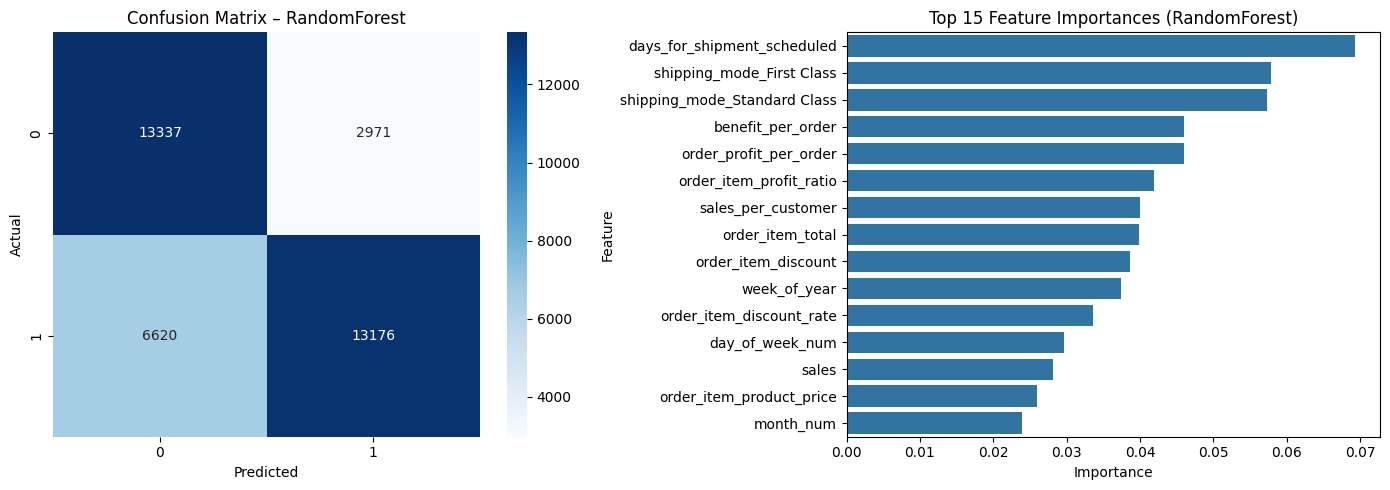

In [14]:
# 12) Visualisations verdict
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix – RandomForest')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Top 15 features
imp = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
sns.barplot(x=imp.values, y=imp.index, orient='h', ax=axes[1])
axes[1].set_title('Top 15 Feature Importances (RandomForest)')
axes[1].set_xlabel('Importance')
axes[1].set_ylabel('Feature')
plt.tight_layout()
plt.show()

# 13) Conclusion Métier

## Que signifie Accuracy ≈ 0.73 ?

Le modèle identifie correctement **73 %** des commandes en tant que « livrée à temps » ou « livrée en retard ».  
Autrement dit, **~27 %** des prédictions sont erronées, ce qui est réaliste sur un jeu de données supply chain déséquilibré.

## Analyse des erreurs (Faux Positifs vs. Faux Négatifs)

| Type d'erreur | Signification | Impact métier |
|---|---|---|
| **Faux Positif (FP)** — Prédit « en retard » mais livré à temps | Actions correctives inutiles (surcoût logistique, re-routage, sur-stockage) | **Coût direct** : dépenses opérationnelles supplémentaires sans nécessité |
| **Faux Négatif (FN)** — Prédit « à temps » mais livré en retard | Retard non anticipé → client insatisfait, pénalités contractuelles, perte de confiance | **Coût indirect élevé** : churn client, réputation, pénalités SLA |

> **Dans un contexte supply chain, les FN sont généralement plus coûteux que les FP.**  
> Il est préférable de sur-anticiper un retard (FP) plutôt que de le rater (FN).  
> Le `class_weight='balanced'` du RandomForest tente d'atténuer ce biais.

## Features clés

- `days_for_shipment_scheduled` : le principal prédicteur – plus le délai prévu est long, plus le risque de retard peut varier.  
- `shipping_mode` : le mode d'expédition (Standard Class vs. First Class) influe directement sur la probabilité de retard.  
- Variables géographiques (region, country) : certaines zones ont un taux de retard structurel plus élevé.

## Limites et prochaines étapes

1. **Feature engineering avancé** : agrégats historiques par client/produit, saisonnalité, jours fériés.  
2. **Optimisation des seuils** : ajuster le threshold de classification pour minimiser les FN selon la matrice de coût métier.  
3. **Hyperparameter tuning** : GridSearch / Optuna pour affiner RandomForest et XGBoost.  
4. **Monitoring en production** : data drift, performance decay, réentraînement périodique.